In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

In [17]:
data = np.load('../data/train.npz')

In [41]:
def show_image(ax, index):
    ax.imshow(data['images'][index])
    ax.set_title(f"Label: {data['labels'][index]}")

def show_by_index(indexes, rows, cols=None):
    if cols is None:
        cols = rows
        
    if len(indexes) != rows * cols:
        raise ValueError(f"Number of indexes must be equal to rows*cols (got {len(indexes)} indexes for rows={rows}, cols={cols})")
    
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

    for i, idx in enumerate(indexes):
        row = i // cols
        col = i % cols
        show_image(axes[row, col], idx)

    plt.tight_layout()
    # Hide axes for better visualization
    for ax in axes.flatten():
        ax.axis('off')
    plt.show()

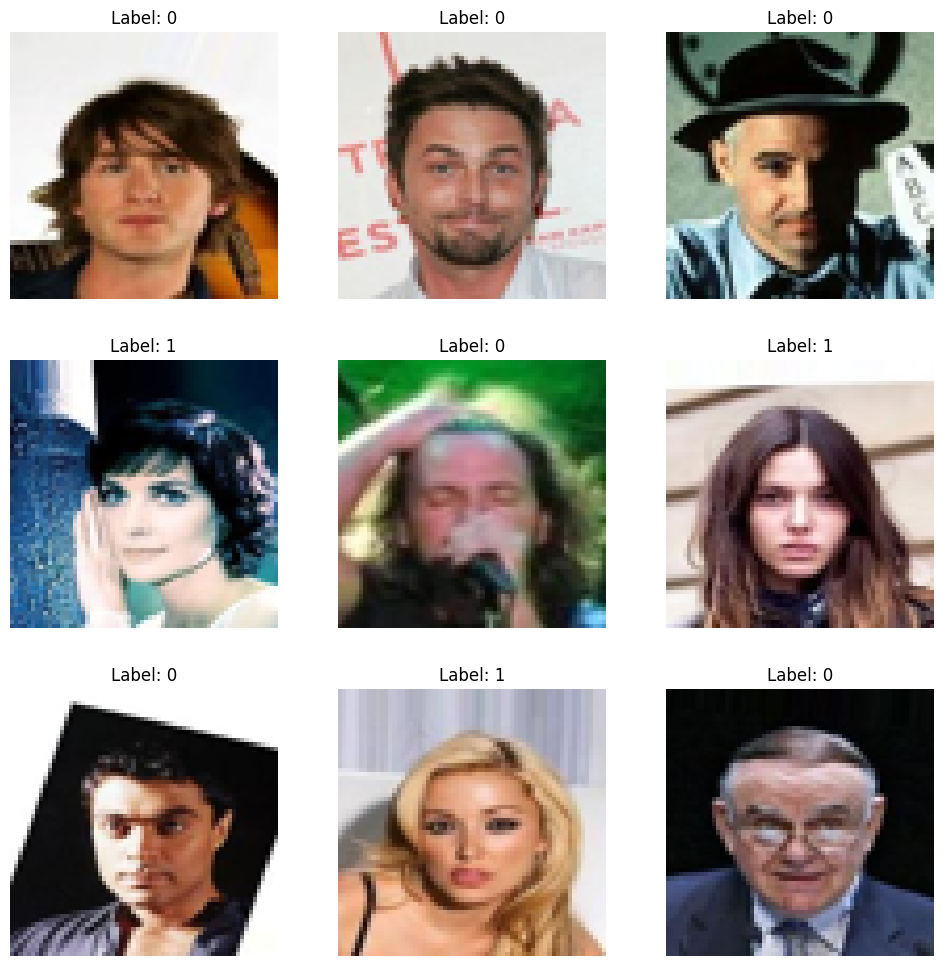

In [42]:
n = 3
random_idx = np.random.randint(0, len(data['images']), n*n)

show_by_index(random_idx, n)


# Metadata exploration

In [33]:
df = pd.read_csv('../data/train_meta.csv')
df['target'] = data['labels']
df.sample(5)

,age,male,pale_skin,smiling,heavy_makeup,big_lips,big_nose,high_cheekbones,oval_face,blond_hair,black_hair,eyeglasses,wearing_lipstick,narrow_eyes,target
27527,0,1,0,1,0,0,1,1,0,0,0,0,0,0,0
17863,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
8620,0,0,0,1,1,1,0,1,0,0,0,0,1,0,1
25579,0,1,0,1,0,1,1,1,0,0,0,0,0,0,0
30302,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0


### Label distribution by columns

In [45]:
def plot_label_distribution_by_column(column):
    plt.figure(figsize=(10, 6))
    df.groupby(column)['target'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
    plt.title(f"Label distribution by {column}")
    plt.xlabel(column)
    plt.ylabel("Proportion")
    plt.legend(title="Label", loc='upper right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

<Figure size 1000x600 with 0 Axes>

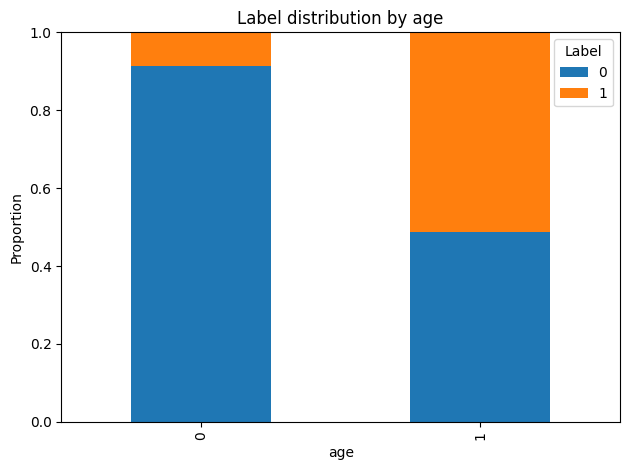

<Figure size 1000x600 with 0 Axes>

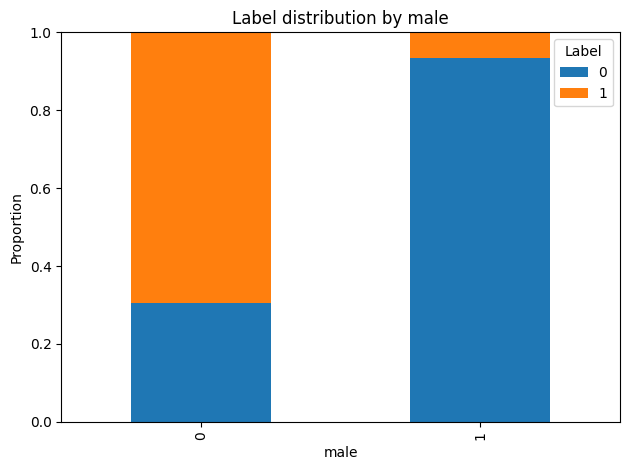

<Figure size 1000x600 with 0 Axes>

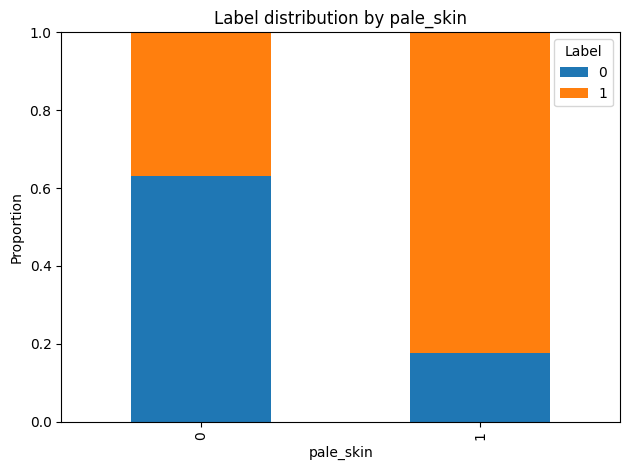

<Figure size 1000x600 with 0 Axes>

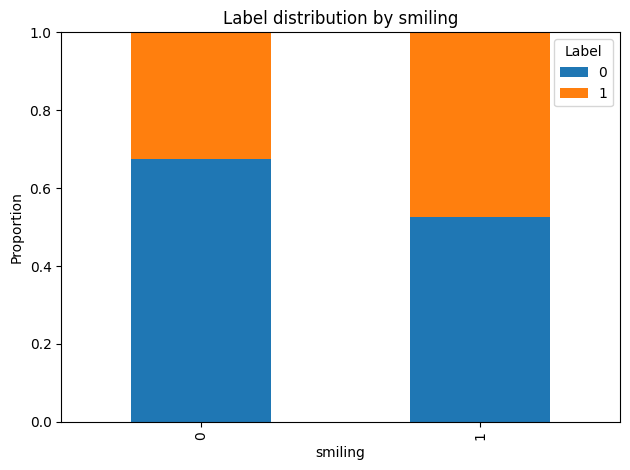

<Figure size 1000x600 with 0 Axes>

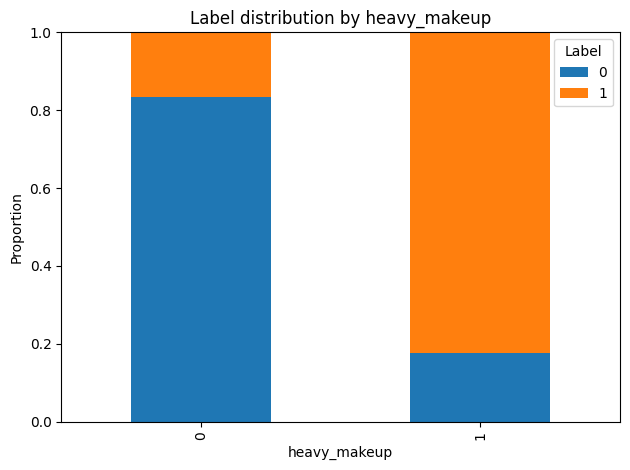

<Figure size 1000x600 with 0 Axes>

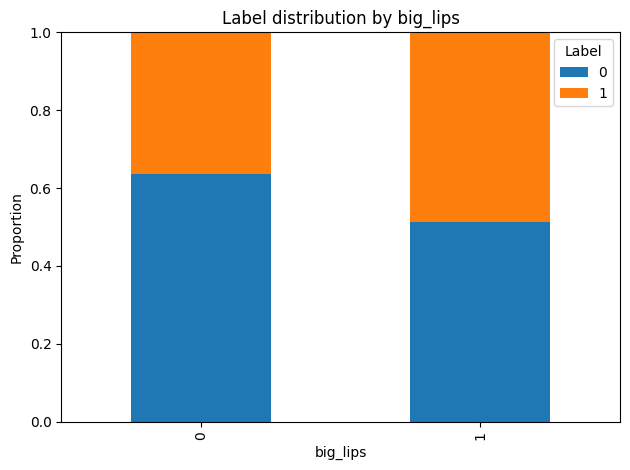

<Figure size 1000x600 with 0 Axes>

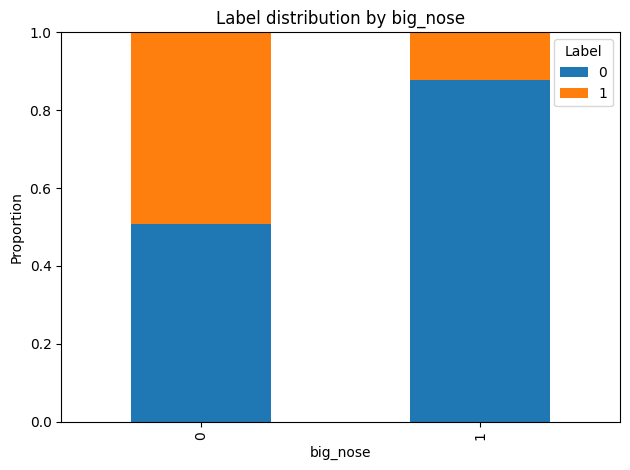

<Figure size 1000x600 with 0 Axes>

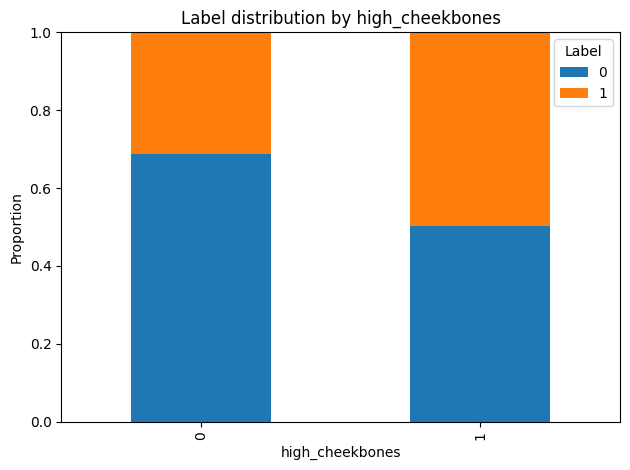

<Figure size 1000x600 with 0 Axes>

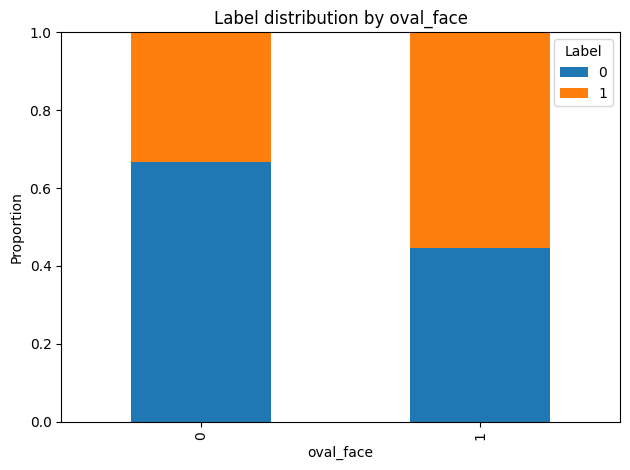

<Figure size 1000x600 with 0 Axes>

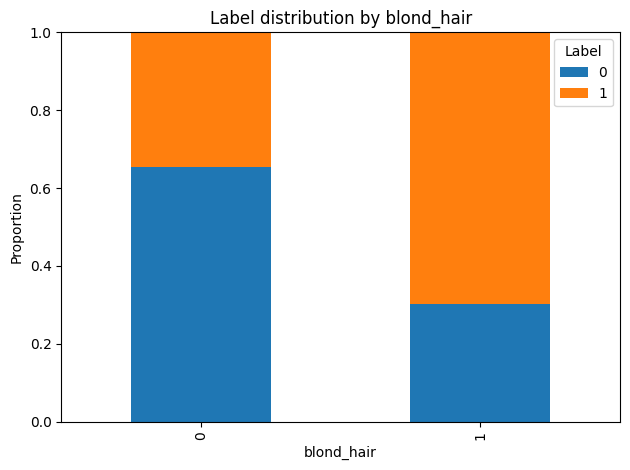

<Figure size 1000x600 with 0 Axes>

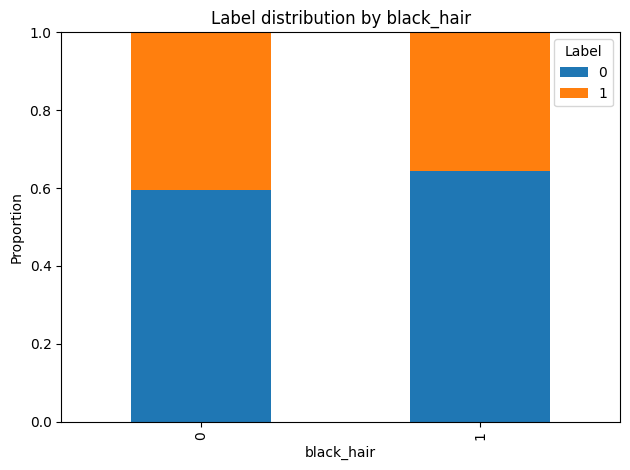

<Figure size 1000x600 with 0 Axes>

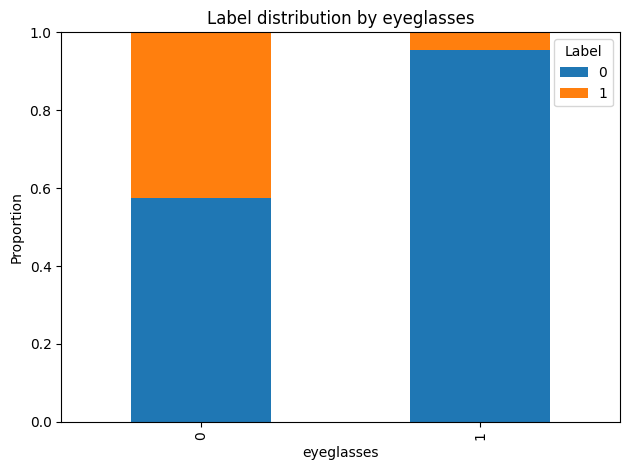

<Figure size 1000x600 with 0 Axes>

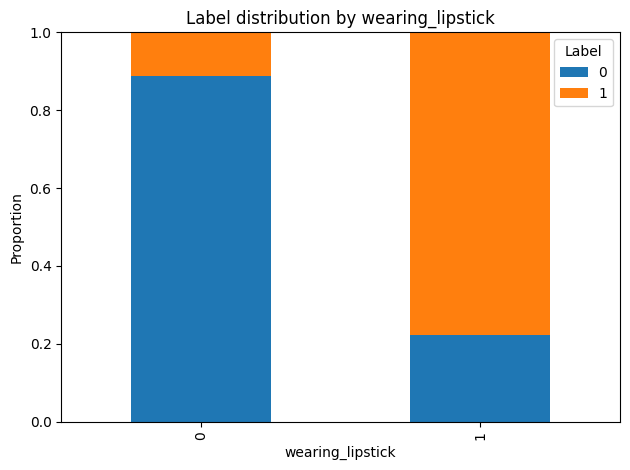

<Figure size 1000x600 with 0 Axes>

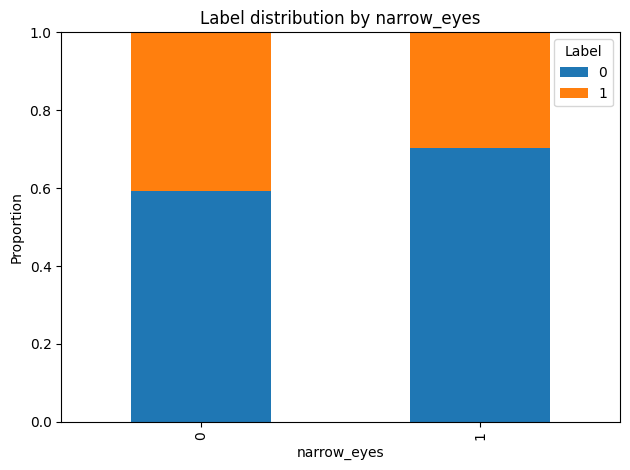

In [46]:
columns = df.columns.drop('target')
for column in columns:
    plot_label_distribution_by_column(column)

## Exploration by columns

In [49]:
def plot_sample_images_by_column(column, n=3):
    unique_values = df[column].unique()
    for value in unique_values:
        sample_indices = df[df[column] == value].index
        if len(sample_indices) >= n:
            selected_indices = np.random.choice(sample_indices, n*n, replace=False)
            print(f"Sample images for {column} = {value}:")
            show_by_index(selected_indices, n)

### Age

Sample images for age = 1:


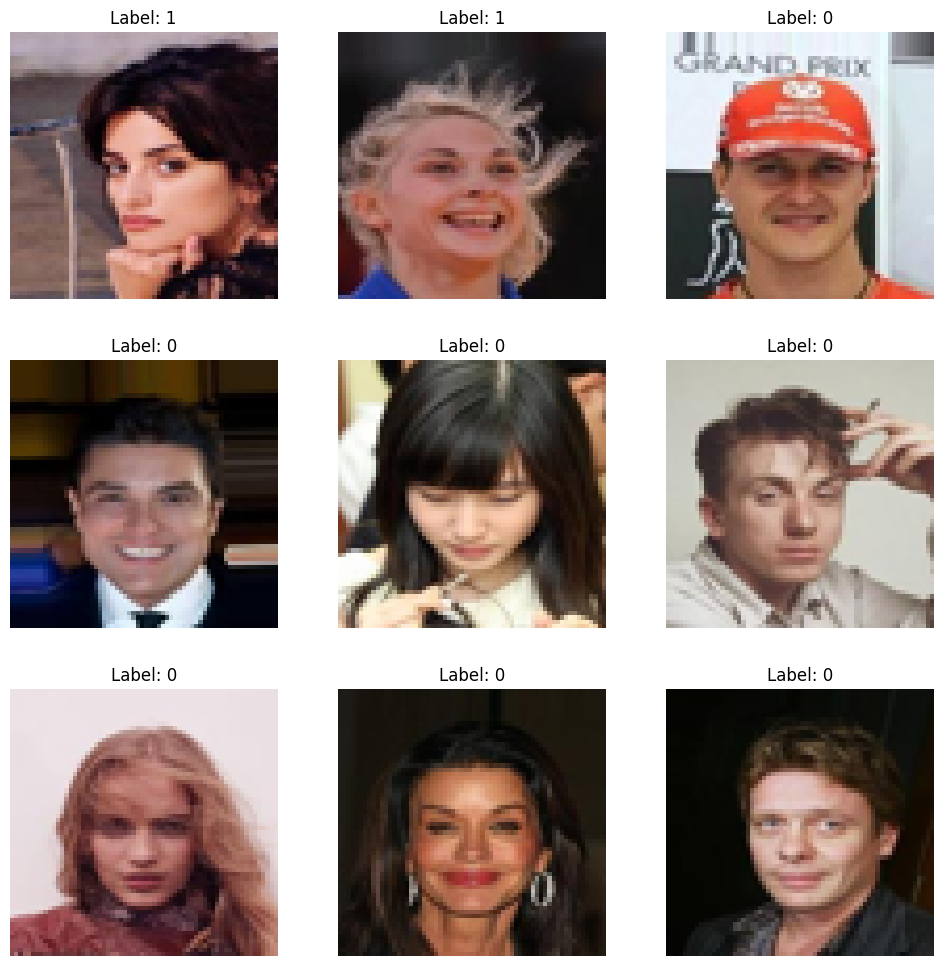

Sample images for age = 0:


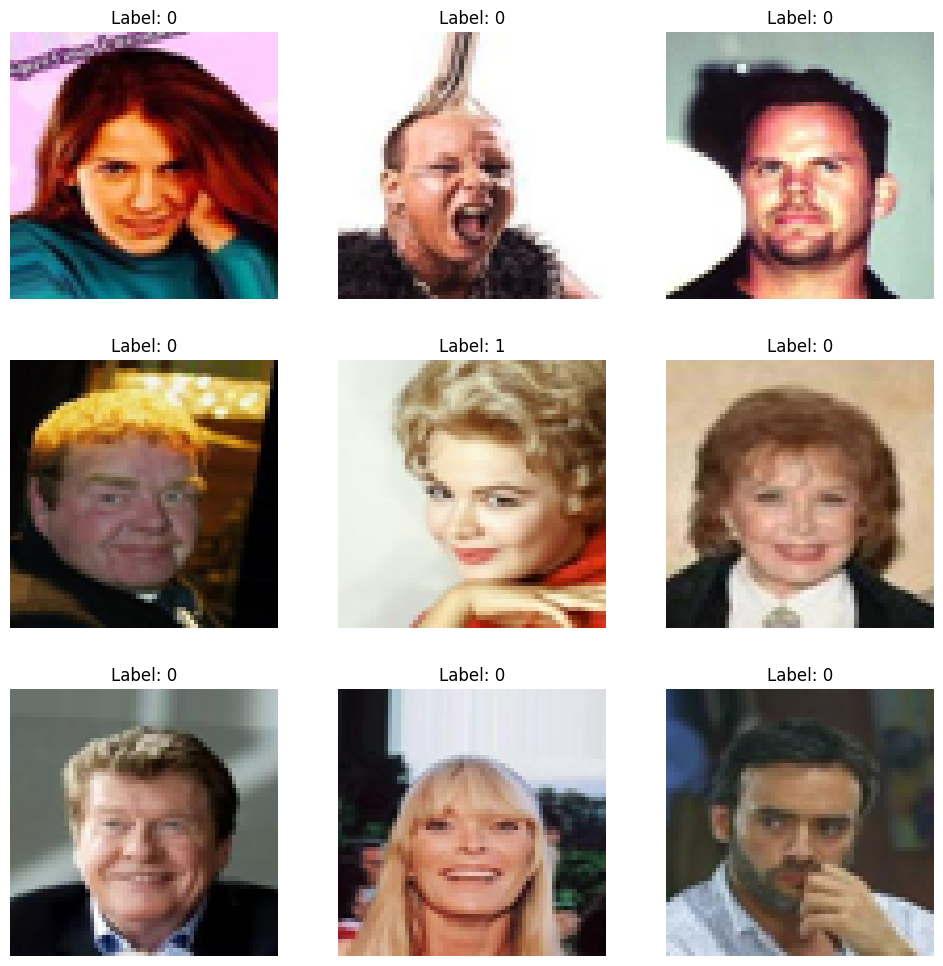

In [50]:
plot_sample_images_by_column('age')